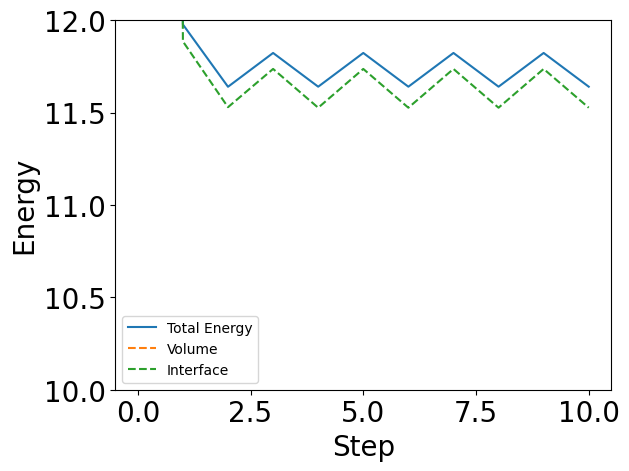

In [4]:
energy = []
volume = []
interface = []
with open("7_0/FE.txt","r") as f:
    lines = f.readlines()
    for line in lines:
        if not len(line.split()):
            continue
        if line.split()[0] =="Energy":
            energy.append(float(line.split()[1]))
        if line.split()[0] =="Volume":
            volume.append(float(line.split()[1]))
        if line.split()[0] =="Interface":
            interface.append(float(line.split()[1]))
import matplotlib.pyplot as plt

time = [i for i in range(len(energy))]
plt.plot(time, energy, label = "Total Energy")
plt.plot(time, volume, linestyle= "--",label = "Volume")
plt.plot(time, interface, linestyle= "--", label = "Interface")
plt.xlabel("Step",fontsize = 20)
plt.ylabel("Energy",fontsize = 20)
plt.ylim(10,12)
plt.tick_params(labelsize = 20)
plt.legend()

(array([ 8., 28., 45., 38., 24., 21., 10.,  3.,  4.,  2.]),
 array([0.0296037 , 0.05445997, 0.07931624, 0.10417251, 0.12902878,
        0.15388505, 0.17874132, 0.20359759, 0.22845385, 0.25331012,
        0.27816639]),
 <BarContainer object of 10 artists>)

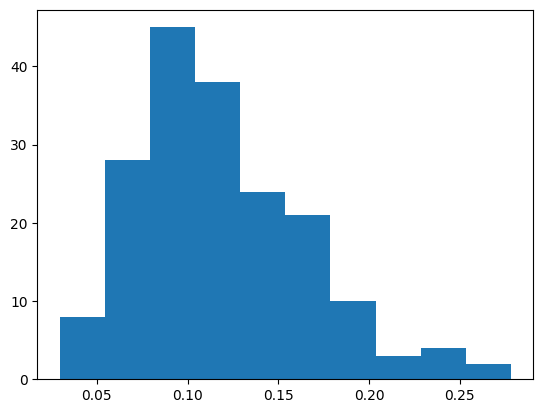

In [1]:
from toolbox import stressTensor
from toolbox import training
import matplotlib.pyplot as plt
import numpy as np
i = 0
dir = "7_1/"
file = "{}.bulk.txt".format(i)

shear = []

tr = training.stressPatterns.from_config(dir, file)
tr._config.load_periodic_tissue_cell_properties()

for cellID,cell in tr._config.cells_.items():
    if cell.crossBoundary_:
        continue
    stress = stressTensor.calculate_stress_tensor_COM_center(tr._config,cellID)
    egvals = np.linalg.eigvalsh(stress)
    max_shear = 0.5 * abs(egvals[-1] - egvals[0])
    shear.append(max_shear)
    for polygonID in cell.polygons_:
        polygon = tr._config.polygons_[polygonID]
        polygon.vtk_scalar_ = max_shear

tr._config.write_periodic_vtk("test.vtk",use_scalar=True)
plt.hist(shear, bins = 10)


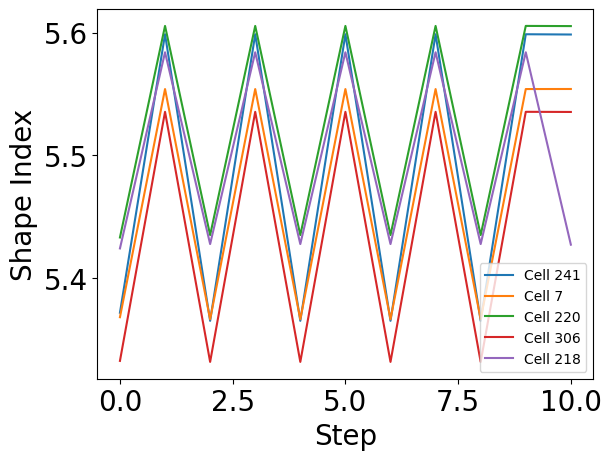

In [7]:
from toolbox import tissueSample
n_iters = 11
dir = "7_1/"
modified_cells = {}
 
with open("{}cellParameters.input".format(dir), "r") as f:
    lines = f.readlines()
    for line in lines:
        if not len(line.split()):
            continue
        modified_cells[int(line.split()[0])] = []

for i in range(n_iters):   
    file = "{}.bulk.txt".format(i)
    sample = tissueSample.Sample.periodic_tissue(dir, file)
    sample.load_periodic_tissue_cell_properties()
    for cellID in modified_cells:
        shape_index = sample.cells_[cellID].shape_index_
        modified_cells[cellID].append(shape_index)

import matplotlib.pyplot as plt
steps = [i for i in range(n_iters)]
# for cellID, shape_index_array in modified_cells.items():
#     for i in range(len(shape_index_array)):
#         plt.axhline(y = shape_index_array[i], xmin = i, xmax= i+1, label = "Cell {}".format(cellID)) 

for cellID, array in modified_cells.items():
    plt.plot(steps, array, label = "Cell {}".format(cellID))
plt.xlabel("Step",fontsize = 20)
plt.ylabel("Shape Index",fontsize = 20)
plt.tick_params(labelsize = 20)
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Define the coordinates of the line segment
x = [0, 1]
y = [0, 1]

# Plot the line segment
plt.plot(x, y, label='Line Segment')

# Add labels and legend
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()

# Show the plot
plt.show()
# Define the starting point
start_point = 0.5

# Define the coordinates of the line segment
x = [start_point, start_point + 1]
y = [0, 0]

# Plot the line segment
plt.plot(x, y, label='Line Segment Parallel to X-axis')

# Add labels and legend
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()

# Show the plot
plt.show()

In [6]:
from toolbox import tissueSample
dir = "7_5/"
for iter in range(3):
    filename = "{}.bulk.txt".format(iter)
    sample = tissueSample.Sample.periodic_tissue(config_dir=dir,input_filename=filename)
    sample.load_periodic_tissue_cell_properties()
    for cellID,cell in sample.cells_.items():
        if cell.crossBoundary_:
            continue
        print(cellID, cell.volume_, cell.shape_index_)



0 1.0020044932376266 5.362028214537873
3 0.9991169354765908 5.378322022641627
5 1.0048897918721182 5.346862368531118
6 0.9966399789095549 5.410430260896438
7 0.9978404689269096 5.386913750683922
10 0.9971662383439448 5.389674574359843
13 0.9992063400809121 5.381760694234896
15 1.0017352325348965 5.363975074930943
16 1.0101874129787478 5.316901135697327
18 0.9999372703563735 5.379392563517945
19 0.9951816963113759 5.404822295416547
20 1.0003422226826353 5.379436711639534
23 0.9997697470790411 5.3796592270344465
24 1.0121018889081201 5.3143231885265045
25 0.9653208037937144 5.548415049733337
28 1.0096391478897626 5.330123141830401
32 0.9763793330927746 5.501716368265701
34 1.0102197762434795 5.321301357384383
36 0.9933317666916295 5.403804998288229
37 0.9912736359952041 5.431531527369834
38 0.9886491769583803 5.445718790518945
39 0.996808392901086 5.403074503206874
40 1.0064178280444533 5.359428686296685
43 0.8864125514481376 5.589195116791951
46 0.9992702072513777 5.375650908536436
48 1

In [1]:
from toolbox import tissueSample
dir = "final/"
samples = {i:tissueSample.Sample.periodic_tissue(config_dir=dir,input_filename="{:07d}.sample.topo".format(i)) for i in range(21)}
for i, sample in samples.items():
    sample.sample_center_ = sample.cells_[211].center_
    sample.time_ = i
    sample.load_periodic_tissue_cell_properties()
    cell = sample.extract_cell(211)
    cell.dump_vtk(dir+"{:07d}.fixed.vtk".format(i))

In [5]:
def load_shape_index_change(sample0:tissueSample.Sample,sample1:tissueSample.Sample):
    cellIDs = []
    for cellID,cell in sample0.cells_.items():
        if cell.crossBoundary_:
            continue
        if cellID not in sample1.cells_:
            continue
        if sample1.cells_[cellID].crossBoundary_:
            continue
        cellIDs.append(cellID)
    diff_shape_indices = {cellID:sample1.cells_[cellID].shape_index_-sample0.cells_[cellID].shape_index_ for cellID in cellIDs}
    for cellID,change in diff_shape_indices.items():
        sample1.cells_[cellID].shape_index_change_ = change

for i in range(1,21):
    load_shape_index_change(samples[i-1],samples[i])

In [3]:
from toolbox import functions
# def create_change_vtk(sample0:tissueSample.Sample,sample1:tissueSample.Sample,filename:str):
def create_change_vtk(sample:tissueSample.Sample,filename:str):

    vertices = []
    total_polygons = 0
    total_polygon_data_points = 0
    for polygonID,polygon in sample.polygons_.items():
        if polygon.crossBoundary_:
            continue
        total_polygons += 1
        total_polygon_data_points += len(polygon.vertices_) + 1
        for vertex in polygon.vertices_:
            vertices.append(vertex)
    vertices = list(set(vertices))
    v_map = functions.mapmaker(vertices)
    with open("{}".format(filename),"w") as f:
        f.write("# vtk DataFile Version 2.0\n")
        f.write("polydata\n")
        f.write("ASCII\n")
        f.write("DATASET POLYDATA\n")
        f.write("POINTS {} double\n".format(len(vertices)))
        for vertexID in vertices:
            for i in range(3):
                f.write("{} ".format(sample.vertices_[vertexID].position_[i]))
            f.write("\n")
        f.write("POLYGONS {} {}\n".format(total_polygons,total_polygon_data_points))
        for polygonID,polygon in sample.polygons_.items():
            if polygon.crossBoundary_:
                continue
            f.write("{} ".format(len(polygon.vertices_)))
            for vertexID in polygon.vertices_:
                f.write("{} ".format(v_map[vertexID]))
            f.write("\n")
        f.write("CELL_DATA {}\n".format(total_polygons))
        # f.write("SCALARS is_fixed double\n")
        # f.write("LOOKUP_TABLE default\n")
        # for polygonID,polygon in sample.polygons_.items():
        #     if polygon.crossBoundary_:
        #         continue
        #     if polygon.is_fixed_:
        #         f.write("1\n")
        #     else:
        #         f.write("0\n")
        # f.write("SCALARS vol_changes double\n")
        # f.write("LOOKUP_TABLE default\n")
        # for polygonID,polygon in sample.polygons_.items():
        #     if polygon.crossBoundary_:
        #         continue
        #     for cellID,cell in sample.cells_.items():
        #         if polygonID in cell.polygons_:
        #             if diff_volumes[cellID] is None:
        #                 f.write("0\n")
        #                 break
        #             else:
        #                 f.write("{:.14f}\n".format(diff_volumes[cellID]))
        #                 break
        f.write("SCALARS shape_index_changes double\n")
        f.write("LOOKUP_TABLE default\n")
        for polygonID,polygon in sample.polygons_.items():
            if polygon.crossBoundary_:
                continue
            for cellID,cell in sample.cells_.items():
                if polygonID in cell.polygons_:
                    if cell.shape_index_change_ is None:
                        f.write("0\n")
                        break
                    else:
                        f.write("{:.14f}\n".format(cell.shape_index_change_))
                        break

for i in range(1,21):
    create_change_vtk(samples[i],dir+"{:07d}.change.vtk".format(i))